In [8]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from itertools import count
import time
import plotly.figure_factory as ff
import plotly.express as px
from tqdm.auto import tqdm
import pickle
from scipy.spatial.distance import cosine
import random
from scipy.stats import spearmanr

import plotly.io as pio
pio.renderers.default = "notebook"

data = Path('data/undir_trials/depnet_undirected.gz')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Exploratory Analysis

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data, usecols=['DEP'], dtype={'DEP': str})
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP ≈ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

Defining Thresholds + Building Networks

In [17]:
# reloading df with the columns i need
df = pd.read_csv(data)
df = df[['ORIGIN', 'DESTINATION', 'DEP']]
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# filtering
DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
# calculating thresholds with bounded range
quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

# creating networks with original uncapped df
for i, threshold in zip(count(0, 0.25), thresholds): # indexing by threshold value
    thresholded_df = df[df['DEP'] >= threshold]
    G = nx.from_pandas_edgelist(thresholded_df, 'ORIGIN', 'DESTINATION')
    
    # save as edgelist
    nx.write_edgelist(G, f'data/undir_trials/{i}_network.txt', delimiter=' ')

C:\Users\User\AppData\Local\Temp\ipykernel_4100\2836395702.py:2: DtypeWarning: Columns (0: N_UIDS_DESTINATION, 1: N_VISITS_DESTINATION, 2: DEP) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data)


In [1]:
%pdb off

Automatic pdb calling has been turned OFF


Applying Link Prediction Pipeline

--- Threshold = 0.25... ---

Nodes: 114812
Edges: 795664


sampling non-edges:   0%|          | 0/397786 [00:00<?, ?edge/s]

sampling non-edges:   0%|          | 0/397786 [00:00<?, ?edge/s]

About to write training graph...
Wrote training graph: 114642 nodes, 397786 edges


  0%|          | 0/1146420 [00:00<?, ?it/s]

...

create_training_data label=0:   0%|          | 0/7 [00:00<?, ?edge/s]

predicting probabilities:   0%|          | 0/4 [00:00<?, ?operator/s]

computing AUC:   0%|          | 0/4 [00:00<?, ?operator/s]

avg       : 0.8163
hadamard  : 0.7959
w-l1      : 0.7755
w-l2      : 0.7959
Computation Time for Threshold 1.0: 4.099




C:\Users\User\AppData\Local\Temp\ipykernel_14344\3976003930.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Threshold', y='Computation_Time', palette='magma')


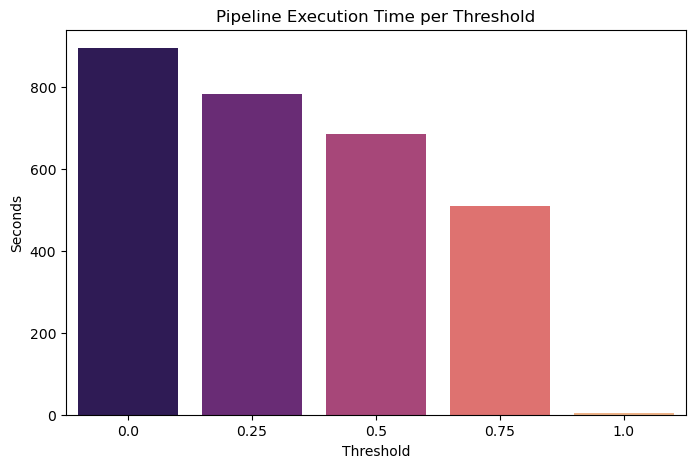

In [ ]:
results = {}
embeddings = {}
graphs = {}
for path in glob.glob('data/undir_trials/*.txt'):
    # extracting name
    path = Path(path)
    name = path.stem.split('_')[0]
    print(f'--- Threshold = {name}... ---\n')<

    # put through pipeline + record computation time
    start_time = time.perf_counter()
    scores, embeddings, G = pipeline.run_pipeline(path, mode='SparseOTF')
    end_time = time.perf_counter()
    comptime = end_time - start_time
    print(f'Computation Time for Threshold {name}: {comptime:.3f}\n\n')

    scores['Computation_Time'] = comptime
    scores[name] = scores
    embeddings[name] = embeddings
    graphs[name] = G

    # saving so i dont have to wait an hour to rerun it if the kernel breaks
    for result in [scores, embeddings, graphs]:
        with open(f"data/undir_trials/results/{result}_{name}.pkl", 'wb') as f:
            pickle.dump(result, f, pickle.HIGHEST_PROTOCOL)

C:\Users\User\AppData\Local\Temp\ipykernel_14344\3246441116.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Threshold', y='Computation_Time', palette='magma')


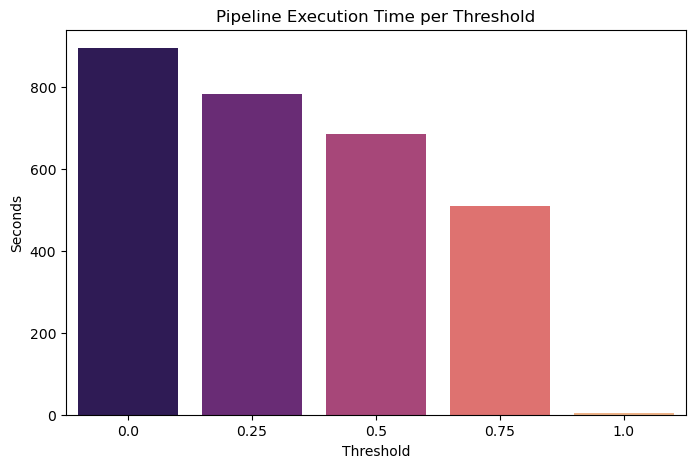

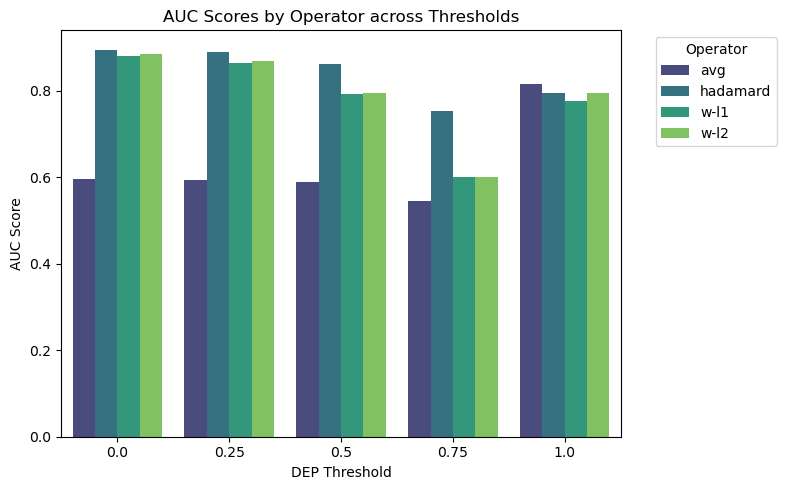

In [12]:
# --- building table ---

# converting to df and sorting
df = pd.DataFrame.from_dict(threshold_results, orient='index')
df.index = df.index.astype(float)
df = df.sort_index()
df.index.name = 'Threshold'
df = df.reset_index()

# runtime analysis plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Threshold', y='Computation_Time', palette='magma')
plt.title('Pipeline Execution Time per Threshold')
plt.xlabel('Threshold')
plt.ylabel('Seconds')
plt.savefig('runtime_analysis.png')

# results plots
df_display = df.copy()

# 4 decimal places for auc scores
auc_cols = ['avg', 'hadamard', 'w-l1', 'w-l2']
for col in auc_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")

# 2 decimal places for time
df_display['Computation_Time'] = df_display['Computation_Time'].apply(lambda x: f"{x:.2f}")

# bar plot
# melting so seaborn can group the operators
df_melted = df.melt(
    id_vars='Threshold', 
    value_vars=['avg', 'hadamard', 'w-l1', 'w-l2'], 
    var_name='Operator', 
    value_name='AUC'
)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted, x='Threshold', y='AUC', hue='Operator', palette='viridis')

# formatting
plt.title('AUC Scores by Operator across Thresholds')
plt.ylabel('AUC Score')
plt.xlabel('DEP Threshold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Operator')
plt.tight_layout()
plt.savefig('auc_operator_barplot.png')
plt.show()

# main plotly table
fig = ff.create_table(df_display)
fig.write_image('prelim_results.png')
fig.show()

Embedding/Geographical Distance Comparison

In [2]:
# --- get results from revised pipeline ---

# getting test/train split once outside the loop
train_neg, test_pos, test_neg = pipeline.prepare_data(
    'data/undir_trials/thresholded_networks/0_network.txt'
)
print("Training graph complete. Moving to pipeline...\n")

# path for saving later
dir_path = Path("data/undir_trials/dim_test/")
dir_path.mkdir(parents=True, exist_ok=True)

for vec_size in np.arange(48, 209, 16):
    print(f'--- Vector Size: {vec_size} ---')
    # put through pipeline + record computation time
    start_time = time.perf_counter()
    cur_scores, cur_emb = pipeline.run_pipeline(
        'train.txt', train_neg, test_pos, test_neg, dim=vec_size, workers=8, mode='SparseOTF'
    )
    end_time = time.perf_counter()
    comptime = end_time - start_time
    print(f'Computation Time for Vector Size {vec_size}: {comptime/60:.3f} minutes.\n')

    # saving so i dont have to wait two hours to rerun it if the kernel breaks
    print('Saving...')
    for data, label in [(cur_scores, 'scores'), (cur_emb, 'embeddings')]:
        with open(dir_path / f"{label}_{int(vec_size)}.pkl", 'wb') as f:
            pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)
    print(f'Saved for vector size {vec_size}.\n')

Nodes: 115355
Edges: 1015920


sampling non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

sampling non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

About to write training graph...
Wrote training graph: 115270 nodes, 507933 edges
Training graph complete. Moving to pipeline...
--- Vector Size: 48 ---


  0%|          | 0/1152700 [00:00<?, ?it/s]

...

create_training_data label=1:   0%|          | 0/507933 [00:00<?, ?edge/s]

create_training_data label=0:   0%|          | 0/507933 [00:00<?, ?edge/s]

predicting probabilities:   0%|          | 0/4 [00:00<?, ?operator/s]

computing AUC:   0%|          | 0/4 [00:00<?, ?operator/s]

avg       : 0.5962
hadamard  : 0.9039
w-l1      : 0.8427
w-l2      : 0.8460
Computation Time for Vector Size 208: 919.974


Saving...
Saved for vector size 208.


In [ ]:
# --- load stuff in ---

# --- metadata ---
print('Loading metadata...')
df = pd.read_csv(data)
orig_df = df[['ORIGIN', 'DESTINATION', 'TAXONOMY_ORIGIN', 'TAXONOMY_DESTINATION', 'DIST_KM']]

# --- scores + embeddings ---
print("Loading pipeline results...")
scores_dict = {}
emb_dict = {}
results_dir = Path("data/undir_trials/dim_test")

# iterate through the files
for file_path in results_dir.glob("*.pkl"):
    # extract label and vector size
    filename_parts = file_path.stem.split('_')
    
    if len(filename_parts) == 2:
        label = filename_parts[0]
        vec_size = int(filename_parts[1])
        
        # load data from pickle file
        with open(file_path, 'rb') as f:
            result = pickle.load(f)
            
        # store in appropriate dict keyed by vec_size
        if label == 'scores':
            scores_dict[vec_size] = result
        elif label == 'embeddings':
            emb_dict[vec_size] = result
        else:
            print(f"Warning: Unknown label '{label}' in filename '{file_path.name}'. Skipping.")

    else:
        print(f"Warning: Unexpected filename format '{file_path.name}'. Skipping.")

# combine into df (set dict keys as rows and sort)
scores_df = pd.DataFrame.from_dict(scores_dict, orient='index').sort_index()
emb_df = pd.DataFrame.from_dict(emb_dict, orient='index').sort_index()

# --- compute embedding distances ---

# create new df with all info for each vec_size
print('Combining DataFrames...')
combined_dfs = {}
correlations = {}
for vec_size in emb_df.index:
    print(f"Analyzing Vector Size: {vec_size}")

    temp_df = orig_df.copy() # temporary df for this iteration
    emb_mapping = emb_df.loc[vec_size].to_dict() # extract embeddings as dict
    
    # map embeddings to origin and destination nodes
    temp_df['ORIGIN_EMB'] = temp_df['ORIGIN'].map(emb_mapping)
    temp_df['DESTINATION_EMB'] = temp_df['DESTINATION'].map(emb_mapping)
    
    # handle nodes that were removed by pipeline LCC filtering and became NaNs
    temp_df = temp_df.dropna(subset=['ORIGIN_EMB', 'DESTINATION_EMB']).reset_index(drop=True)
    
    # --- add cosine distance ---

    # convert to ndarray for speed
    A = np.array(temp_df['ORIGIN_EMB'].tolist())
    B = np.array(temp_df['DESTINATION_EMB'].tolist())
    
    # calculate dot product and norms for all rows
    dot_product = np.sum(A * B, axis=1)
    norm_A = np.linalg.norm(A, axis=1)
    norm_B = np.linalg.norm(B, axis=1)
    
    # protect against division by zero
    denominator = norm_A * norm_B
    denominator[denominator == 0] = 1e-10 
    
    # apply back to df
    temp_df['EMB_DIST_COS'] = 1 - (dot_product / denominator)

    # creating category for same vs different POI
    temp_df['SAME_POI'] = temp_df['TAXONOMY_ORIGIN'] == temp_df['TAXONOMY_DESTINATION']
    temp_df['EDGE_TYPE'] = temp_df['SAME_POI'].map({
        True: 'Same POI Category', 
        False: 'Cross-Category'
    })

    # --- correlations (spearman) ---
    
    corr, p_value = spearmanr(temp_df['EMB_DIST_COS'], temp_df['DIST_KM'])
    correlations[vec_size] = corr

    # save
    combined_dfs[vec_size] = temp_df

print("\nData loading complete.")

Loading metadata...


C:\Users\User\AppData\Local\Temp\ipykernel_22604\3843085946.py:5: DtypeWarning: Columns (0: N_UIDS_DESTINATION, 1: N_VISITS_DESTINATION, 2: DEP) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data)


Loading pipeline results...
Combining DataFrames...
Analyzing Vector Size: 48


MemoryError: Unable to allocate 4.54 GiB for an array with shape (12680910, 48) and data type float64

In [ ]:
# plotting

# --- bar plot ---

plot_df = scores_df.reset_index().rename(columns={'index': 'vec_size'})
melted_df = plot_df.melt(id_vars='vec_size', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='vec_size', y='Score', hue='Metric')

plt.title('Pipeline Scores by Vector Size', fontsize=15)
plt.xlabel('Vector Size (vec_size)')
plt.ylabel('Metric Score')
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('data/undir_trials/imgs/vec_size_barplot.png')

# --- scatterplot ---

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten() 

# iterate through dfs and plot for each
for i, (vec_size, df) in enumerate(combined_dfs.items()):

    ax = axes[i]
    
    sns.scatterplot(
        data=df, 
        x='DIST_KM',
        y='EMB_DIST_COS',
        hue='EDGE_TYPE', # color by POI relationship
        ax=ax, 
        alpha=0.5, 
        s=10,
        legend=(i == 0) # only draw the legend on the first plot
    )
    
    # add title with correlation value
    corr_val = correlations[vec_size] 
    ax.set_title(f"Size: {vec_size}\nSpearman: {corr_val:.3f}")

axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('data/undir_trials/imgs/geo_vs_emb_scatter.png')
